In [103]:
import numpy as np
import matplotlib.pyplot as plt

## Strategy 1 :-

- **Cheka doesnt know p_truth and keeps updating its belief on MI6's messages based on previous messages sent and their success rates ie it doesnt know the actual p_truth and keeps updating it**

In [104]:
class Game:
    def __init__(self):
        self.safehouse = np.zeros(3)
        self.P = np.zeros(3)
        self.location = 0
        self.game_round = 0
        self.accuracy = 0.6
        self.both = 0
        self.mi6 = 0
        self.cheka = 0
        self.null = 0

    def hide_the_file(self):
        self.location = np.random.randint(3)
        self.safehouse[self.location] = 1
        self.safehouse[(self.location+1)%3] = 0
        self.safehouse[(self.location+2)%3] = 0
        return self.location

    def report(self):
        self.P[self.location] = self.accuracy
        self.P[(self.location +1)%3] = (1 - self.accuracy)/2
        self.P[(self.location +2)%3] = (1 - self.accuracy)/2
        info = np.random.choice([0,1,2],p = self.P)
        return info

class mi6:
    def __init__(self,p_truth = 0.6,p_follow = 0.7):
        self.p_truth = p_truth
        self.p_follow = p_follow
        self.score = 0
        self.successful_bluffs = 0
        self.failed_bluffs = 0
        self.truthful_msgs = 0

    def send_message(self,report):
        correct = np.random.choice([1,0],p=[self.p_truth,1 - self.p_truth])
        if correct :
            return report , correct
        else:
            return np.random.choice([(report+1)%3,(report+2)%3]) ,correct

    def search(self,report):
        follow = np.random.choice([1,0],p=[self.p_follow,1 - self.p_follow])
        if follow :
            return report
        else :
            return np.random.choice([(report+1)%3,(report+2)%3])

class cheka:
    def __init__(self):
        self.prior = np.array([1/3,1/3,1/3])
        self.posterior = np.zeros(3)
        self.score = 0
        self.hits = 1
        self.misses = 1
        self.p_truth_hat = self.hits / (self.hits + self.misses)

    def update_belief(self,message,p_truth):
        likelihood = np.zeros(3)
        likelihood[message] = p_truth
        likelihood[(message+1)%3] = (1-p_truth)/2
        likelihood[(message+2)%3] = (1-p_truth)/2

        total = np.sum(likelihood*self.prior)

        if total != 0:
            self.posterior = (likelihood * self.prior)/ np.sum(likelihood*self.prior)
        else:
            self.posterior[message] = p_truth
            self.posterior[(message+1)%3] = (1-p_truth)/2
            self.posterior[(message+2)%3] = (1-p_truth)/2

        return self.posterior

    def search(self):
        max_val = np.max(self.posterior)
        candidates = np.where(self.posterior == max_val)[0]
        return np.random.choice(candidates)

    def update_truth_estimate(self, message, true_location):
        if message == true_location:
            self.hits += 1
        else:
            self.misses += 1
        self.p_truth_hat = self.hits / (self.hits + self.misses)

In [105]:
def simulate_game(game : Game,mi6 : mi6,cheka : cheka,p_truth = 0.6,p_follow = 0.7,accuracy = 0.6):

    game.accuracy = accuracy
    mi6.p_truth = p_truth
    mi6.p_follow = p_follow



    game.game_round += 1

    location = game.hide_the_file()
    report = game.report()

    msg , correct = mi6.send_message(report)

    posterior = cheka.update_belief(msg, cheka.p_truth_hat)

    mi6_selection = mi6.search(report)
    cheka_selection = cheka.search()

    if not correct and cheka_selection != location:
        mi6.successful_bluffs += 1
    elif not correct and cheka_selection == location:
        mi6.failed_bluffs += 1
    else:
        mi6.truthful_msgs += 1

    if mi6_selection == location and cheka_selection == location:
        mi6.score += 3
        cheka.score += 3
        game.both +=1

    elif mi6_selection == location and cheka_selection != location:
        mi6.score += 10
        game.mi6 +=1
    elif mi6_selection != location and cheka_selection == location:
        cheka.score += 10
        game.cheka += 1
    else:
        game.null +=1

    cheka.update_truth_estimate(msg, location)

    return posterior[location]

In [106]:
def realisation(N =5000,pt = 0.6,pf = 0.7,acc = 0.6):
    game = Game()
    MI6 = mi6()
    Cheka = cheka()

    total = 0
    for _ in range(N) :
        total += simulate_game(game, MI6, Cheka,p_truth=pt,p_follow=pf,accuracy=acc)

    avg_posterior = total/N
    print('-------------------------------------------------------------------------------------------')
    print(f"Game Accuracy = {game.accuracy*100}% | p_truth = {MI6.p_truth} | p_follow = {MI6.p_follow}")
    print()
    print(f"MI6's total score = {MI6.score}\n"
          f"Cheka's total score = {Cheka.score}\n"
          f"Number of truthful messages = {MI6.truthful_msgs}\n"
          f"Number of successful bluffs = {MI6.successful_bluffs}\n"
          f"Number of failed bluffs = {MI6.failed_bluffs}\n"
          f"Average posterior probability assigned to the true location by Cheka = {avg_posterior : .4f}\n"
          f"Cheka's final estimate of MI6's p_truth (p_truth_hat) = {Cheka.p_truth_hat:.4f}")

    print()
    print()
    print(
        f"No. of Times Both found file = {game.both}\n"
        f"No. of Times Only MI6 found file = {game.mi6}\n"
        f"No. of Times Only Cheka found file = {game.cheka}\n"
        f"No. of Times No one found file = {game.null}\n"
    )
    print('-------------------------------------------------------------------------------------------')
    print()


In [107]:
p = np.array([0,0.25,0.5,0.75,1])

for i in p:
    realisation(pt = i)

-------------------------------------------------------------------------------------------
Game Accuracy = 60.0% | p_truth = 0.0 | p_follow = 0.7

MI6's total score = 16390
Cheka's total score = 12350
Number of truthful messages = 0
Number of successful bluffs = 2974
Number of failed bluffs = 2026
Average posterior probability assigned to the true location by Cheka =  0.3582
Cheka's final estimate of MI6's p_truth (p_truth_hat) = 0.2015


No. of Times Both found file = 1130
No. of Times Only MI6 found file = 1300
No. of Times Only Cheka found file = 896
No. of Times No one found file = 1674

-------------------------------------------------------------------------------------------

-------------------------------------------------------------------------------------------
Game Accuracy = 60.0% | p_truth = 0.25 | p_follow = 0.7

MI6's total score = 18086
Cheka's total score = 10966
Number of truthful messages = 1218
Number of successful bluffs = 2290
Number of failed bluffs = 1492
Ave

In [108]:
p = np.array([0.5,0.7,0.9,1])

for i in p:
    realisation(pf = i)

-------------------------------------------------------------------------------------------
Game Accuracy = 60.0% | p_truth = 0.6 | p_follow = 0.5

MI6's total score = 12777
Cheka's total score = 15057
Number of truthful messages = 2945
Number of successful bluffs = 1652
Number of failed bluffs = 403
Average posterior probability assigned to the true location by Cheka =  0.3484
Cheka's final estimate of MI6's p_truth (p_truth_hat) = 0.4418


No. of Times Both found file = 989
No. of Times Only MI6 found file = 981
No. of Times Only Cheka found file = 1209
No. of Times No one found file = 1821

-------------------------------------------------------------------------------------------

-------------------------------------------------------------------------------------------
Game Accuracy = 60.0% | p_truth = 0.6 | p_follow = 0.7

MI6's total score = 15164
Cheka's total score = 12664
Number of truthful messages = 3014
Number of successful bluffs = 1600
Number of failed bluffs = 386
Aver

In [109]:
acc = np.array([0.6,0.8,0.4,0.2])

for i in acc:
    realisation(acc = i)

-------------------------------------------------------------------------------------------
Game Accuracy = 60.0% | p_truth = 0.6 | p_follow = 0.7

MI6's total score = 14400
Cheka's total score = 13050
Number of truthful messages = 3004
Number of successful bluffs = 1582
Number of failed bluffs = 414
Average posterior probability assigned to the true location by Cheka =  0.3549
Cheka's final estimate of MI6's p_truth (p_truth_hat) = 0.4514


No. of Times Both found file = 1360
No. of Times Only MI6 found file = 1032
No. of Times Only Cheka found file = 897
No. of Times No one found file = 1711

-------------------------------------------------------------------------------------------

-------------------------------------------------------------------------------------------
Game Accuracy = 80.0% | p_truth = 0.6 | p_follow = 0.7

MI6's total score = 17920
Cheka's total score = 14370
Number of truthful messages = 3007
Number of successful bluffs = 1804
Number of failed bluffs = 189
Ave

## Strategy 2 :-

- **Cheka knows p_truth and updates its belief of location based upon the p_truth**

In [110]:
# line number 16 - posterior = cheka.update_belief(msg, p_truth) only the second argument requires change

def simulate_game_strategy2(game : Game,mi6 : mi6,cheka : cheka,p_truth = 0.6,p_follow = 0.7,accuracy = 0.6):

    game.accuracy = accuracy
    mi6.p_truth = p_truth
    mi6.p_follow = p_follow

    game.game_round += 1

    location = game.hide_the_file()
    report = game.report()

    msg , correct = mi6.send_message(report)

    posterior = cheka.update_belief(msg, p_truth)

    mi6_selection = mi6.search(report)
    cheka_selection = cheka.search()

    if not correct and cheka_selection != location:
        mi6.successful_bluffs += 1
    elif not correct and cheka_selection == location:
        mi6.failed_bluffs += 1
    else:
        mi6.truthful_msgs += 1

    if mi6_selection == location and cheka_selection == location:
        mi6.score += 3
        cheka.score += 3
        game.both +=1

    elif mi6_selection == location and cheka_selection != location:
        mi6.score += 10
        game.mi6 +=1
    elif mi6_selection != location and cheka_selection == location:
        cheka.score += 10
        game.cheka += 1
    else:
        game.null +=1

    cheka.update_truth_estimate(msg, location)

    return posterior[location]

In [111]:
def realisation2(N =5000,pt = 0.6,pf = 0.7,acc = 0.6):
    game = Game()
    MI6 = mi6()
    Cheka = cheka()

    total = 0
    for _ in range(N) :
        total += simulate_game_strategy2(game, MI6, Cheka,p_truth=pt,p_follow=pf,accuracy=acc)

    avg_posterior = total/N
    print('-------------------------------------------------------------------------------------------')
    print(f"Game Accuracy = {game.accuracy*100}% | p_truth = {MI6.p_truth} | p_follow = {MI6.p_follow}")
    print()
    print(f"MI6's total score = {MI6.score}\n"
          f"Cheka's total score = {Cheka.score}\n"
          f"Number of truthful messages = {MI6.truthful_msgs}\n"
          f"Number of successful bluffs = {MI6.successful_bluffs}\n"
          f"Number of failed bluffs = {MI6.failed_bluffs}\n"
          f"Average posterior probability assigned to the true location by Cheka = {avg_posterior : .4f}\n"
          f"Cheka's final estimate of MI6's p_truth (p_truth_hat) = {Cheka.p_truth_hat:.4f}")

    print()
    print()
    print(
        f"No. of Times Both found file = {game.both}\n"
        f"No. of Times Only MI6 found file = {game.mi6}\n"
        f"No. of Times Only Cheka found file = {game.cheka}\n"
        f"No. of Times No one found file = {game.null}\n"
    )
    print('-------------------------------------------------------------------------------------------')
    print()


In [112]:
p = np.array([0,0.25,0.5,0.75,1])

for i in p:
    realisation2(pt = i)

-------------------------------------------------------------------------------------------
Game Accuracy = 60.0% | p_truth = 0.0 | p_follow = 0.7

MI6's total score = 15548
Cheka's total score = 12338
Number of truthful messages = 0
Number of successful bluffs = 2957
Number of failed bluffs = 2043
Average posterior probability assigned to the true location by Cheka =  0.4029
Cheka's final estimate of MI6's p_truth (p_truth_hat) = 0.1943


No. of Times Both found file = 1156
No. of Times Only MI6 found file = 1208
No. of Times Only Cheka found file = 887
No. of Times No one found file = 1749

-------------------------------------------------------------------------------------------

-------------------------------------------------------------------------------------------
Game Accuracy = 60.0% | p_truth = 0.25 | p_follow = 0.7

MI6's total score = 17237
Cheka's total score = 11687
Number of truthful messages = 1258
Number of successful bluffs = 2226
Number of failed bluffs = 1516
Ave

## Experiment 1

**Always Truth v/s Always Bluffing**

- If he always tells truth and games accuracy is good enough then cheka is at more advantage than at always bluffing though both help as always bluffing will will make cheka eliminate options but always truth will give it one particular direction
- Going Pure bluffing is not the best it should bluff by 1/3 as pure bluffing helps cheka eliminate options


## Experiment 2

**Does blindly following the report always lead to the highest score?**

- No. it also depends on the game accuracy how accurate the report is sending the intel

## Experiment 3

**How does the reliability of intelligence affect the usefulness of bluffing?**

- 1/3 is the threshold that makes cheka go from believing the message to help it eliminate other options
- Ie if accuracy < 50% then p_truth should be high for the best results as it will be more successful in bluffing
- If accuracy > 50% p_truth should be 1/3 for best results as then cheka wont have an idea whether to eliminate or follow

In [113]:
realisation2(pt = 0.9,acc=0.1)
realisation2(pt = 0.8,acc=0.1)
realisation2(pt=0.7,acc=0.1)
realisation2(pt= 1/3,acc=0.1)
realisation2(pt = 1/3,acc = 0.8)
realisation2(pt=0.1,acc=0.8)
realisation2(pt=0.2,acc=0.8)

-------------------------------------------------------------------------------------------
Game Accuracy = 10.0% | p_truth = 0.9 | p_follow = 0.7

MI6's total score = 8190
Cheka's total score = 4130
Number of truthful messages = 4540
Number of successful bluffs = 265
Number of failed bluffs = 195
Average posterior probability assigned to the true location by Cheka =  0.1642
Cheka's final estimate of MI6's p_truth (p_truth_hat) = 0.1345


No. of Times Both found file = 370
No. of Times Only MI6 found file = 708
No. of Times Only Cheka found file = 302
No. of Times No one found file = 3620

-------------------------------------------------------------------------------------------

-------------------------------------------------------------------------------------------
Game Accuracy = 10.0% | p_truth = 0.8 | p_follow = 0.7

MI6's total score = 8097
Cheka's total score = 6317
Number of truthful messages = 3979
Number of successful bluffs = 561
Number of failed bluffs = 460
Average pos

**Explain how Bayesian updates helped Cheka make better decisions than simply trusting every message.**

- Suppose ptruth was less than 0.5 than cheka would mostly get to the wrong location if it simply trusted every message sent as mi6 is bluffing more often but bayesian update helped in avoiding so as if ptruth was less then bayesian would help cheka to make it understand that its is absolutely not this location as shown in the message so it helps is eliminate some locations so now it chooses any of the other two locations.

**Based on your simulations, do the strategies “Always Tell the Truth” or “Always Bluff” perform well over many missions?
Explain why a randomized (mixed) strategy can often be more effective.**

- Explained above why p_truth should be 1/3

**Suppose, you were designing MI6’s strategy. What values of ptruth and pfollow would you choose? Justify your answer using
the results of your simulation.**

- p_truth = 1/3 as accuracy > 0.5
- p_follow = 1 as accuracy > 0.5

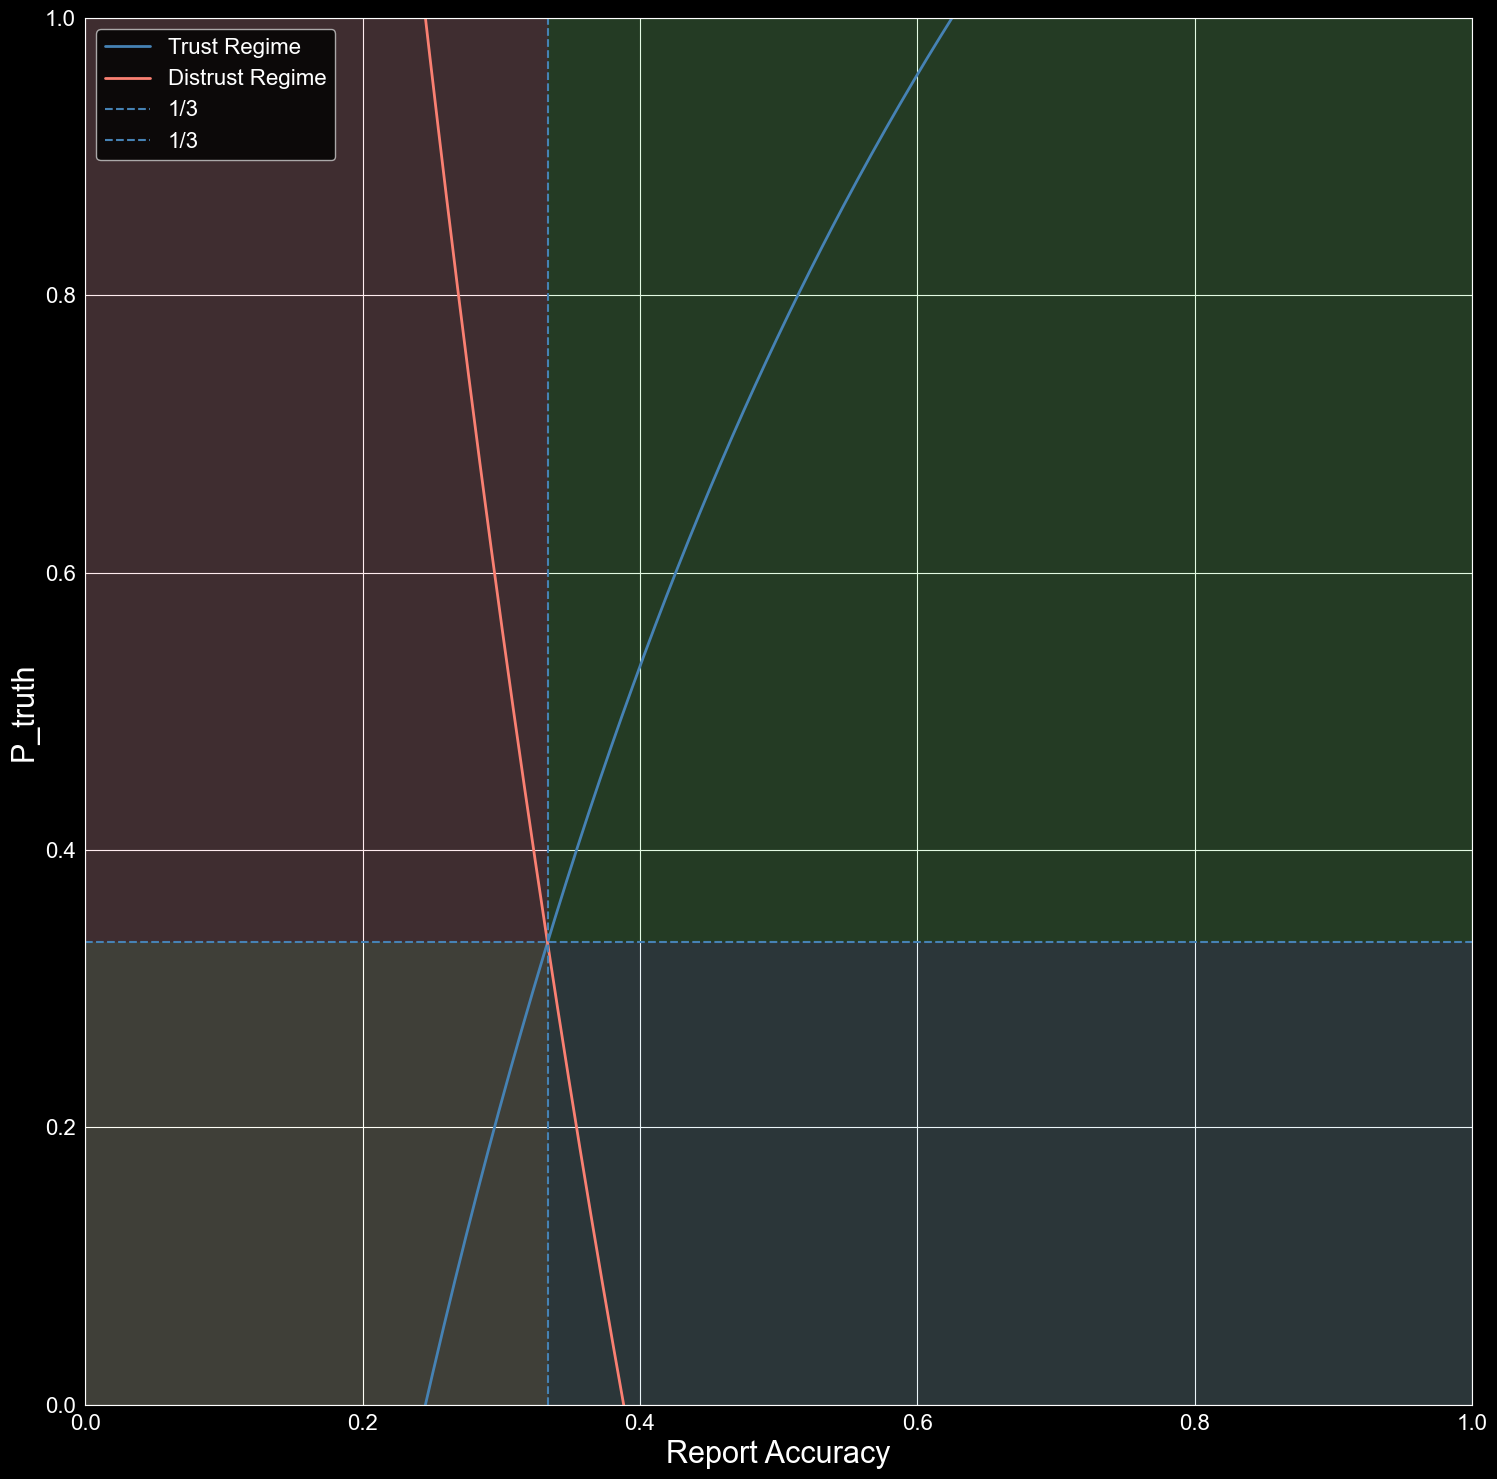

In [136]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

COLOR_BOTTOM_LEFT  = 'lightyellow'
COLOR_BOTTOM_RIGHT = 'lightblue'
COLOR_TOP_LEFT     = 'lightpink'
COLOR_TOP_RIGHT    = 'lightgreen'
OPACITY             = 0.25
SPLIT_X = 1/3
SPLIT_Y = 1/3

AXIS_LABEL_SIZE = 22
TICK_LABEL_SIZE = 16
LEGEND_FONT_SIZE = 16

fig, ax = plt.subplots(figsize=(15, 15))

x = np.linspace(0, 1, 500)
y1 = (53 * x - 13) / (7 * (1 + 3 * x))
y2 = (33 - 85 * x) / (7 * (3 * x + 1))

ax.plot(x, y1, color='steelblue', linewidth=2, label='Trust Regime')
ax.plot(x, y2, color='salmon', linewidth=2, label='Distrust Regime')

ax.axvline(x=SPLIT_X, color='steelblue', linewidth=1.5, linestyle='--',label = '1/3')
ax.axhline(y=SPLIT_Y, color='steelblue', linewidth=1.5, linestyle='--',label = '1/3')

# Four rectangles: (x0, y0, width, height, color)
rectangles = [
    (0,       0,       SPLIT_X,     SPLIT_Y,     COLOR_BOTTOM_LEFT),
    (SPLIT_X, 0,       1 - SPLIT_X, SPLIT_Y,     COLOR_BOTTOM_RIGHT),
    (0,       SPLIT_Y, SPLIT_X,     1 - SPLIT_Y, COLOR_TOP_LEFT),
    (SPLIT_X, SPLIT_Y, 1 - SPLIT_X, 1 - SPLIT_Y, COLOR_TOP_RIGHT),
]

for x0, y0, w, h, color in rectangles:
    rect = patches.Rectangle((x0, y0), w, h, facecolor=color, alpha=OPACITY, edgecolor='none')
    ax.add_patch(rect)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('Report Accuracy', fontsize=AXIS_LABEL_SIZE)
ax.set_ylabel('P_truth', fontsize=AXIS_LABEL_SIZE)
ax.tick_params(axis='both', which='major', labelsize=TICK_LABEL_SIZE)
ax.legend(loc='upper left', fontsize=LEGEND_FONT_SIZE)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

-------------------------------------------------------------------------------------------
Game Accuracy = 60.0% | p_truth = 0.3333333333333333 | p_follow = 1

MI6's total score = 22621
Cheka's total score = 9681
Number of truthful messages = 1668
Number of successful bluffs = 1970
Number of failed bluffs = 1362
Average posterior probability assigned to the true location by Cheka =  0.3333
Cheka's final estimate of MI6's p_truth (p_truth_hat) = 0.3283


No. of Times Both found file = 1047
No. of Times Only MI6 found file = 1948
No. of Times Only Cheka found file = 654
No. of Times No one found file = 1351

-------------------------------------------------------------------------------------------

